# 1.1 Loading the data

In [16]:
import pandas as pd

usarrests_path = "../stat-214-gsi/lab0/data/USArrests.csv"
statecoord_path = "../stat-214-gsi/lab0/data/stateCoord.csv"

usa = pd.read_csv(usarrests_path)
coord = pd.read_csv(statecoord_path)

# Clean whitespace
usa["State"] = usa["State"].astype(str).str.strip()
coord["State"] = coord['State         '].astype(str).str.strip()


# 1.2 Manipulating the data

In [17]:
arrests = pd.merge(usa, coord, on="State", how="inner")

# Check merge worked: should usually be 50 states
print("rows usa:", len(usa))
print("rows coord:", len(coord))
print("rows arrests:", len(arrests))

# Check missing matches (if any)
missing = sorted(set(usa["State"]) - set(arrests["State"]))
print("missing after merge:", missing)

arrests.head()

rows usa: 50
rows coord: 50
rows arrests: 40
missing after merge: ['New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Rhode Island', 'South Carolina', 'South Dakota', 'West Virginia']


,State,Murder,Assault,UrbanPop,Rape,State,lon,lat
0,Alabama,13.2,236,58,21.2,Alabama,-86.592392,34.735676
1,Alaska,10.0,263,48,44.5,Alaska,-168.187471,53.330810
2,Arizona,8.1,294,80,31.0,Arizona,-111.615136,36.246377
3,Arkansas,8.8,190,50,19.5,Arkansas,-92.240455,36.374502
4,California,9.0,276,91,40.6,California,-120.386476,34.034180


# 1.3 Visualizing the data

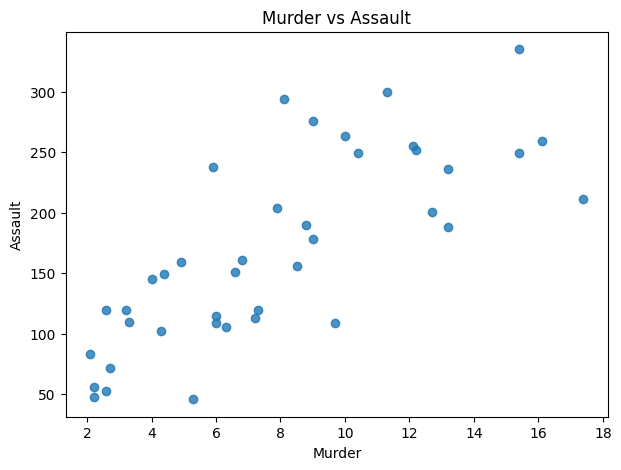

In [18]:
import matplotlib.pyplot as plt     
plt.figure(figsize=(7,5))
plt.scatter(arrests["Murder"], arrests["Assault"], alpha=0.8)
plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault")
plt.show()

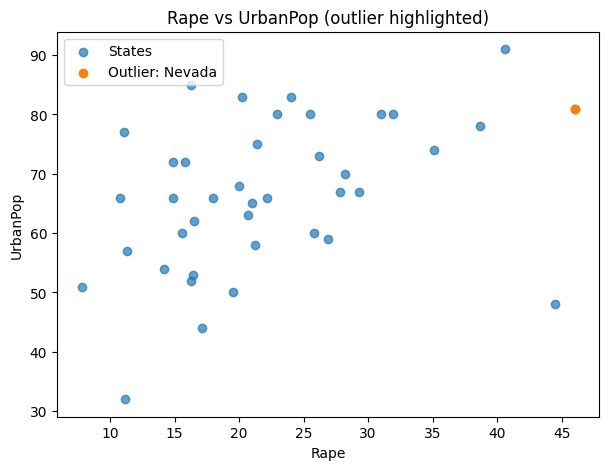

'Nevada'

In [19]:
out_idx = arrests["Rape"].idxmax()
out_state = arrests.loc[out_idx, "State"]

plt.figure(figsize=(7,5))
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0.7, label="States")
plt.scatter(arrests.loc[out_idx, "Rape"], arrests.loc[out_idx, "UrbanPop"],
            label=f"Outlier: {out_state}")
plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Rape vs UrbanPop (outlier highlighted)")
plt.legend()
plt.show()

out_state

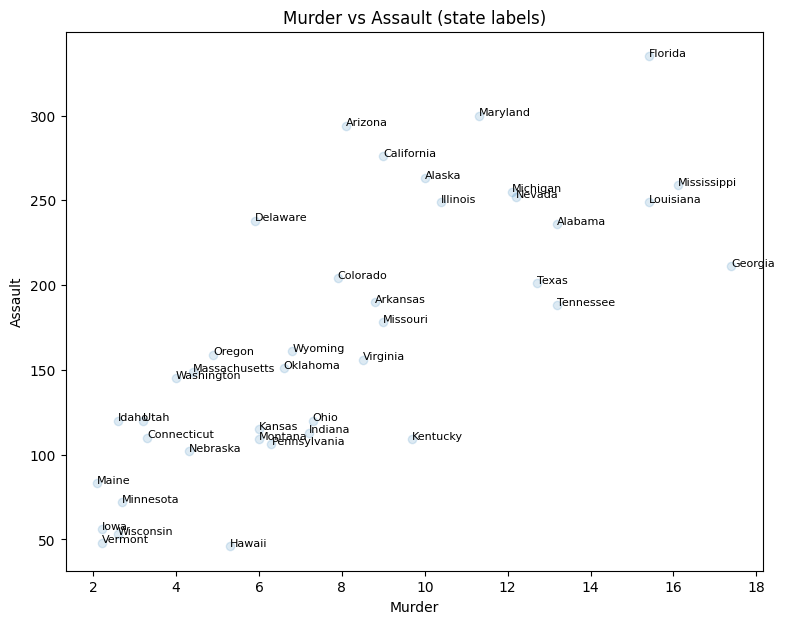

In [20]:
plt.figure(figsize=(9,7))
plt.scatter(arrests["Murder"], arrests["Assault"], alpha=0.15)

for _, row in arrests.iterrows():
    plt.annotate(row["State"], (row["Murder"], row["Assault"]), fontsize=8)

plt.xlabel("Murder")
plt.ylabel("Assault")
plt.title("Murder vs Assault (state labels)")
plt.show()

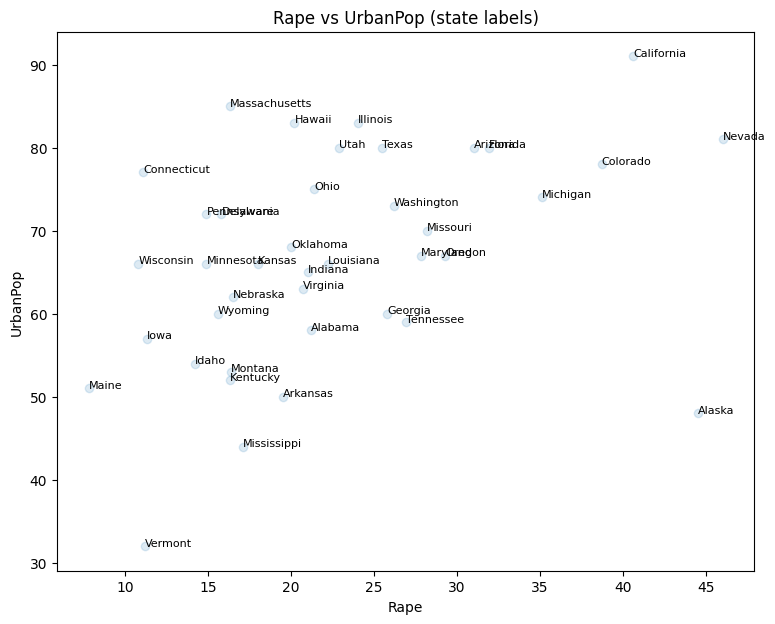

In [21]:
plt.figure(figsize=(9,7))
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0.15)

for _, row in arrests.iterrows():
    plt.annotate(row["State"], (row["Rape"], row["UrbanPop"]), fontsize=8)

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("Rape vs UrbanPop (state labels)")
plt.show()

# 1.4 Regression

In [23]:
arrests_no_MA = arrests.drop(columns=["Murder", "Assault"])
arrests_no_MA.head()

,State,UrbanPop,Rape,State,lon,lat
0,Alabama,58,21.2,Alabama,-86.592392,34.735676
1,Alaska,48,44.5,Alaska,-168.187471,53.330810
2,Arizona,80,31.0,Arizona,-111.615136,36.246377
3,Arkansas,50,19.5,Arkansas,-92.240455,36.374502
4,California,91,40.6,California,-120.386476,34.034180


In [24]:
import numpy as np
from sklearn.linear_model import LinearRegression

X = arrests[["Rape"]].to_numpy()
y = arrests["UrbanPop"].to_numpy()

lr = LinearRegression().fit(X, y)
yhat = lr.predict(X)
resid = y - yhat

print("coef:", lr.coef_[0])
print("intercept:", lr.intercept_)

coef: 0.5603074549219778
intercept: 54.10989148790316


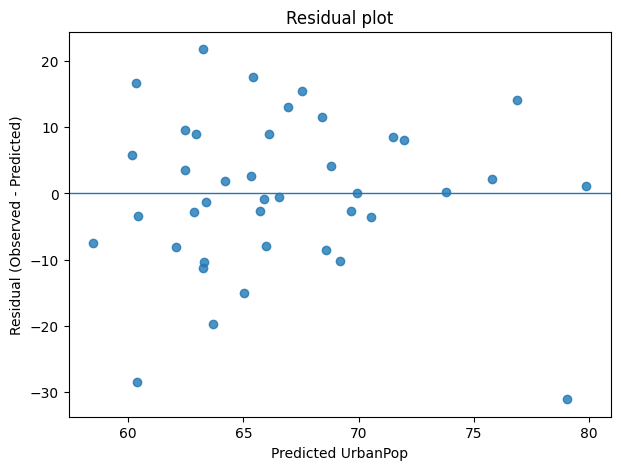

In [25]:
plt.figure(figsize=(7,5))
plt.scatter(yhat, resid, alpha=0.8)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted UrbanPop")
plt.ylabel("Residual (Observed - Predicted)")
plt.title("Residual plot")
plt.show()

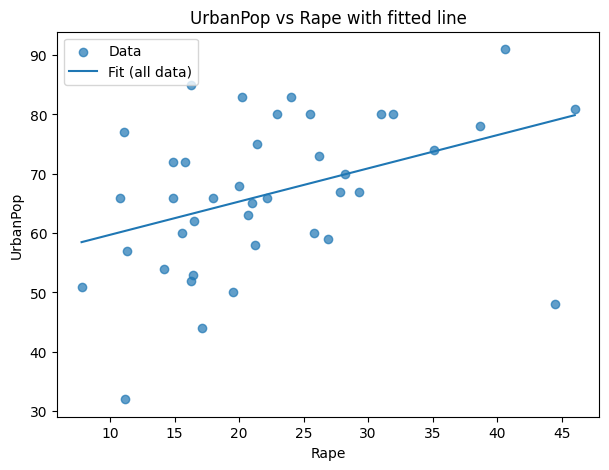

In [26]:
xgrid = np.linspace(arrests["Rape"].min(), arrests["Rape"].max(), 200).reshape(-1, 1)
ygrid = lr.predict(xgrid)

plt.figure(figsize=(7,5))
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0.7, label="Data")
plt.plot(xgrid[:,0], ygrid, label="Fit (all data)")  # blue by default
plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("UrbanPop vs Rape with fitted line")
plt.legend()
plt.show()

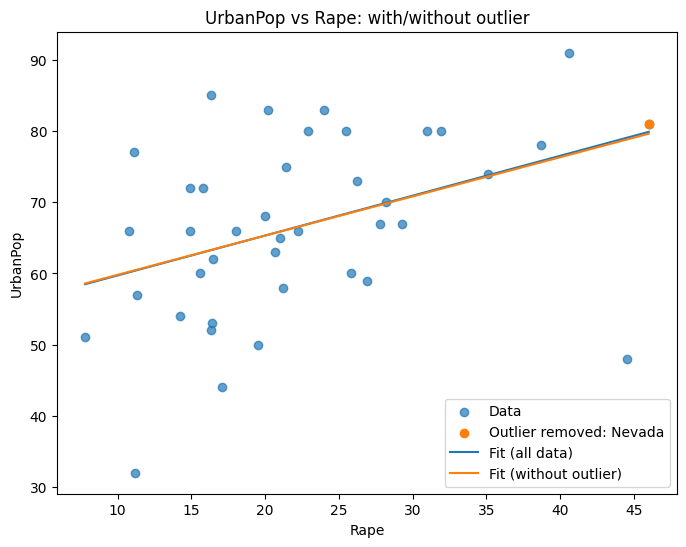

In [27]:
mask = np.ones(len(arrests), dtype=bool)
mask[out_idx] = False

X2 = X[mask]
y2 = y[mask]

lr2 = LinearRegression().fit(X2, y2)
ygrid2 = lr2.predict(xgrid)

plt.figure(figsize=(8,6))
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0.7, label="Data")
plt.scatter(arrests.loc[out_idx, "Rape"], arrests.loc[out_idx, "UrbanPop"],
            label=f"Outlier removed: {out_state}")

plt.plot(xgrid[:,0], ygrid, label="Fit (all data)")          # first line
plt.plot(xgrid[:,0], ygrid2, label="Fit (without outlier)")  # second line (red if you want, see below)

plt.xlabel("Rape")
plt.ylabel("UrbanPop")
plt.title("UrbanPop vs Rape: with/without outlier")
plt.legend()
plt.show()

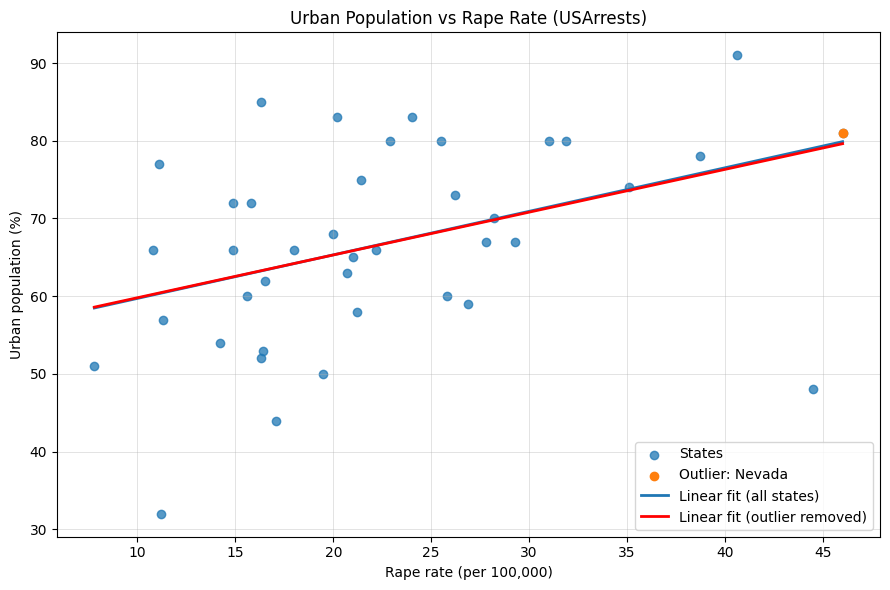

In [28]:
plt.figure(figsize=(9,6))
plt.scatter(arrests["Rape"], arrests["UrbanPop"], alpha=0.75, label="States")
plt.scatter(arrests.loc[out_idx, "Rape"], arrests.loc[out_idx, "UrbanPop"],
            alpha=1.0, label=f"Outlier: {out_state}")

plt.plot(xgrid[:,0], ygrid, linewidth=2, label="Linear fit (all states)")
plt.plot(xgrid[:,0], ygrid2, linewidth=2, color="red", label="Linear fit (outlier removed)")

plt.title("Urban Population vs Rape Rate (USArrests)")
plt.xlabel("Rape rate (per 100,000)")
plt.ylabel("Urban population (%)")
plt.legend()
plt.grid(True, linewidth=0.5, alpha=0.5)
plt.tight_layout()
plt.show()